## Module_3: Idiopathic Pulmonary Fibrosis

## Team Members:
Kai-Tang Tseng, Sara Elster

## Project Title:
Interpolation Algorithms for .....



## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## Disease Background: Idiopathic Pulmonary Fibrosis


* <b>Definition  </b>: Idiopathic (cause not known) pulmonary (lung) fibrosis (excess collagen in connective or interstitial tissue).


* <b>Prevalence & incidence : </b>
    * Prevalence : 1.25-63 Cases per 100,000 population (More common in North America than Europe) (Rozenberg, et al. 2020)
    * Incidence : 40,000 people diagnosed with IPF Annually in the U.S. (Leonard-Duke, et al., 2024)


* <b>Risk factors (genetic, lifestyle) </b> : Increased age, male sex, and smoking history. (Rozenberg, et al. 2020) Genetic can also lead to predisposition such as mutation in Surfactant Protein Relatd Genes and MUC 5B Promotoer and Toll-Interacting Protein and telomere dysfunction. (Duhig 2022)


* <b>Symptoms  </b>: Dyspnea, Nonproductive Cough, Fatique, Death (Median Survival of About three years from diagnosis)


    * IFP Patient can also develop or have concurrent diseases such as Chronic Obstructive Pulmonary Disease (COPD), Cardiovascular Diseases (Including Pulmonary Hypertension, Venous Thromboembolic Disease, Congestive Heart Failure, Coronary Artery Disease, Gastroesophageal Reflux Disease), Lung Cancer, Obstructive Sleep Apnea, and Mental Health Concerns (Anxiety and Depression). (Though the reason for increase prevalence of comorbidites is not known, perhaps it is all related to aging - telomeres dysfunction.)  (Rozenberg, et al. 2020)


* <b>Standard of care treatment(s) </b>:


    * Phamacological Treatment of IPF such as Antifibrotic Drugs : Pirfenidone, Nintedanib, which is shown to attenuate lung function decline. (Still on ongoing field of research, Nintedanib Treatment may also worsten IPF with increased Endothelial Cell Apoptosis and Pericyte-To-Myofibroblast Transition due to Endothelial-Pericyte coupling.)
   
    * Oxygen Therapy, Pulmonary Rehabilitation, Nutrition


    * Lung Transplant


    * Palliative Care : Medical care focused on providing relief from symptoms, pain, and stress of serious illness to improve quality of life.
 
        (Leonard-Duke, et al., 2024 ; Rozenberg, et al. 2020 )


* <b>Biological mechanisms (anatomy, organ physiology, cell & molecular physiology) </b> : Following epithelial cell injury, there is an abnormal would healing process where there is an increased secretion of growth factors (such as Transforming Growth Factor Beta TGFB), increase of fibroblasts and myofibroblasts which lead to interest interstitial fibrosis. (Duhig, 2022)

## Data-Set: 

Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

The data is collected from a Bleomycin-Induced Lung Injury Mice Model, where Bleomycin is injected in the the lung of the mcie subject, leading to lung inflammation and massive fibrosis. This is used to model Idiopathic Pulmonary Fibrosis in mice. Afterward, the lung is extracted and then fixed with Paraformaldehyde (so it does not rot) and then mount it in gel or wax to slice with a cryotome. The slides are then mounted on a glass microscope slide, and the immunohistochemistry (IHC) stain with Fluorescent Labeled Antibody which binds to the protein of interest (Utilizing Desmin Stain to identify Myofibroblasts). They are viewed upder a microscope to capture a digital images. 

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*

#### 1. Analysing Percentage of Fibrotic Tissues

The original code for this data anlysis is written by Prof. Peirce-Cottler, later modified and optimized by Kai-Tang Tseng and Sara Elster to include most data as well as improving efficiency.

The datasets is consisting of black and white pixels with black pixel representing healthy lung tissues and white pixel representing fibrotic tissues. 

NOTE : This current datasets can have artifact of vasculature where it incorrectly labels the blood vessels with a bright white ring while it is not a fibrotic tissue. This is the limitation of this dataset.

For our interpolation model, we 

We included all data points given as listed in "Filenames and Depths for Students.csv" with the exception of data points between the depths of 5000 and 7000. This data range is used to be the validation for interpolation.

In [70]:
'''Module 3: count black and white pixels and compute the percentage of white pixels in a .jpg image and extrapolate points'''


from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import os

# Tell python the current directory you are in
directory = os.getcwd()

# Extract data from the Filenames and Depths for Students.csv
data = pd.read_csv(os.path.join(directory, "Filenames and Depths for Students.csv"))

# 1. Define the long column name as a variable to keep code clean
depth_col = 'Depth from lung surface (in micrometers) where image was acquired'

# 2. Filter the ENTIRE DataFrame first
# data_filtered = data[(data[depth_col] < 5000) | (data[depth_col] > 7000)]
data_filtered = data.drop_duplicates(subset=[depth_col], keep='first')

# 3. NOW extract your lists from the filtered version
depths = data_filtered[depth_col].tolist()
filenames = data_filtered['Filenames'].tolist()

# 4. Build your full paths using the filtered filenames
filenames_complete = [os.path.join(directory, file) for file in filenames]

images = []
white_counts = []
black_counts = []
white_percents = []

# Build the list of all the images you are analyzing

for filename in filenames:
    img = cv2.imread(filename, 0)
    images.append(img)

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    white = np.sum(binary == 255)
    black = np.sum(binary == 0)

    white_counts.append(white)
    black_counts.append(black)
    white_percents.append((white/(white+black))*100)

for i in range(len(filenames)):
    print(colored(f'{filenames[i]}:', "red"))
    print()
    print(colored("Pixel count in image:", "yellow"))
    print(colored(f"White pixels in image {filenames[i]}: {white_counts[i]}"), "white")
    print(colored(f"Black pixels in image {filenames[i]}: {black_counts[i]}", "blue"))
    print()
    print(colored("Percent white pixels:", "yellow"))
    print(f'{white_percents[i]:.2f}% White | Depth: {depths[i]} microns')
    print()

df = pd.DataFrame({
    "Filenames": filenames,
    "Depths": depths,
    "White percents": white_percents
})

df.to_csv("Percent_White_Pixels.csv", index=False)

print("The .csv file 'Percent_White_Pixels.csv' has been created.")

images/MASK_SK658 Llobe ch010039.jpg:

Pixel count in image:
White pixels in image images/MASK_SK658 Llobe ch010039.jpg: 21648 white
Black pixels in image images/MASK_SK658 Llobe ch010039.jpg: 4172656

Percent white pixels:
0.52% White | Depth: 15 microns

images/MASK_SK658 Llobe ch010021.jpg:

Pixel count in image:
White pixels in image images/MASK_SK658 Llobe ch010021.jpg: 23900 white
Black pixels in image images/MASK_SK658 Llobe ch010021.jpg: 4170404

Percent white pixels:
0.57% White | Depth: 30 microns

images/MASK_SK658 Llobe ch010017.jpg:

Pixel count in image:
White pixels in image images/MASK_SK658 Llobe ch010017.jpg: 27561 white
Black pixels in image images/MASK_SK658 Llobe ch010017.jpg: 4166743

Percent white pixels:
0.66% White | Depth: 45 microns

images/MASK_SK658 Llobe ch010036.jpg:

Pixel count in image:
White pixels in image images/MASK_SK658 Llobe ch010036.jpg: 29677 white
Black pixels in image images/MASK_SK658 Llobe ch010036.jpg: 4164627

Percent white pixels:
0.71%

#### 2. Interpolating

The original code for this data anlysis is written by Prof. Peirce-Cottler.

Interpolation is the process of approximating the location of a data point based on other given data. 

##### 2.1 Interpolating Linear

The Interpolating Point chosen for the follow graph was a depth of 6000.

The interpolated point is at the x-coordinate 2345.0 and y-coordinate 1.5608000755310059.


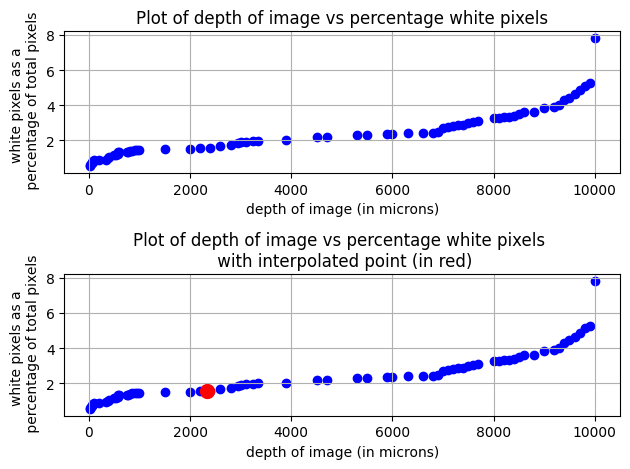

In [71]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
    "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='linear')
interpolate_point = i(interpolate_depth)
print(colored(
f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a \n percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels \n with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a \n percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

##### 2.2 Interpolating Quadratic


The interpolated point is at the x-coordinate 2345.0 and y-coordinate 1.5523349828950626.


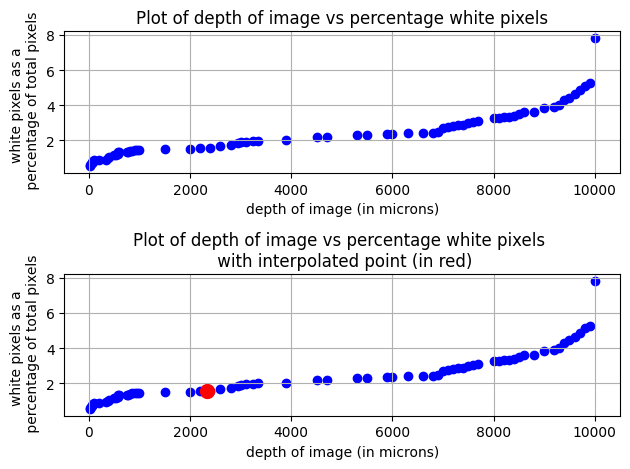

In [72]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
    "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(
f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a \n percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels \n with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a \n percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

##### 2.3 Interpolating Cubic


The interpolated point is at the x-coordinate 2345.0 and y-coordinate 1.553384676308929.


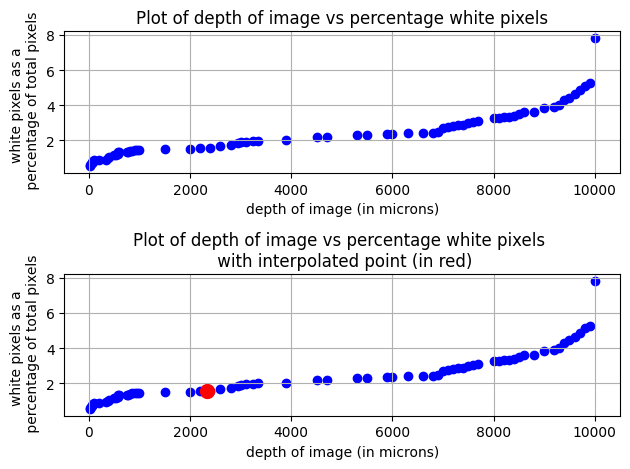

In [73]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
    "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='cubic')
interpolate_point = i(interpolate_depth)
print(colored(
f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a \n percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels \n with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a \n percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

#### 3. Validation of Interpolated Points

We perform the interpolations with three methods : linear, quadratic, and cubic interpolations. We excluded dataset from a depth of 5000-7000 to test our interpolation results.

Here we perform a calulation of interpolation at a depth of 6000 at using the different method in comparison with the actual result.

In [74]:
# Idea interpolate at 6000 for three different method, compare to actual and determine relative and absolute.

# Filter depths and white percents lists to include depths excluding 5000-7000
new_depths = []
new_white_percents = []

for i in range(len(depths)):
    if (depths[i] < 5000) or (depths[i] > 7000):
        new_depths.append(depths[i])
        new_white_percents.append(white_percents[i])

x = new_depths
y = new_white_percents

# Test point 1: depth = 5500; actual percent = 2.3134231567382812
interpolate_depth = float(5500)
actual_percent = 2.3134231567382812

# Linear
i = interp1d(x, y, kind='linear')
interpolate_point_linear = i(interpolate_depth)
linear_abs_error = abs(actual_percent - interpolate_point_linear)
linear_rel_error = (linear_abs_error/actual_percent) * 100
print(colored(f'Test Point 1 Depth: {interpolate_depth}', 'yellow'))
print(colored(f'Actual % white pixels: {actual_percent}%.', 'blue'))
print(colored(f'% white pixels (linear interpolation): {interpolate_point_linear}.', "green"))
print(colored(f'Linear Interpolation Absolute Error: {linear_abs_error}.', 'red'))
print(colored(f'Linear Interpolation Relative Error: {linear_rel_error}%.', 'red'))

# Quadratic
i = interp1d(x, y, kind='quadratic')
interpolate_point_quadratic = i(interpolate_depth)
quad_abs_error = abs(actual_percent - interpolate_point_quadratic)
quad_rel_error = (quad_abs_error/actual_percent) * 100
print(colored(f'% white pixels (quadratic interpolation): {interpolate_point_quadratic}.', "green"))
print(colored(f'Quadratic Interpolation Absolute Error: {quad_abs_error}.', 'red'))
print(colored(f'Quadratic Interpolation Relative Error: {quad_rel_error}%.', 'red'))

# Cubic
i = interp1d(x, y, kind='cubic')
interpolate_point_cubic = i(interpolate_depth)
cub_abs_error = abs(actual_percent - interpolate_point_quadratic)
cub_rel_error = (cub_abs_error/actual_percent) * 100
print(colored(f'% white pixels (cubic interpolation): {interpolate_point_cubic}.', "green"))
print(colored(f'Quadratic Interpolation Absolute Error: {cub_abs_error}.', 'red'))
print(colored(f'Quadratic Interpolation Relative Error: {cub_rel_error}%.\n', 'red'))


# Test point 2: depth = 6000; actual percent = 2.3686885833740234
interpolate_depth = float(6000)
actual_percent = 2.3686885833740234

# Linear
i = interp1d(x, y, kind='linear')
interpolate_point_linear = i(interpolate_depth)
linear_abs_error = abs(actual_percent - interpolate_point_linear)
linear_rel_error = (linear_abs_error/actual_percent) * 100
print(colored(f'Test Point 2 Depth: {interpolate_depth}', 'yellow'))
print(colored(f'Actual % white pixels: {actual_percent}%.', 'blue'))
print(colored(f'% white pixels (linear interpolation): {interpolate_point_linear}.', "green"))
print(colored(f'Linear Interpolation Absolute Error: {linear_abs_error}.', 'red'))
print(colored(f'Linear Interpolation Relative Error: {linear_rel_error}%.', 'red'))


# Quadratic
i = interp1d(x, y, kind='quadratic')
interpolate_point_quadratic = i(interpolate_depth)
quad_abs_error = abs(actual_percent - interpolate_point_quadratic)
quad_rel_error = (quad_abs_error/actual_percent) * 100
print(colored(f'% white pixels (quadratic interpolation): {interpolate_point_quadratic}.', "green"))
print(colored(f'Quadratic Interpolation Absolute Error: {quad_abs_error}.', 'red'))
print(colored(f'Quadratic Interpolation Relative Error: {quad_rel_error}%.', 'red'))


# Cubic
i = interp1d(x, y, kind='cubic')
interpolate_point_cubic = i(interpolate_depth)
cub_abs_error = abs(actual_percent - interpolate_point_quadratic)
cub_rel_error = (cub_abs_error/actual_percent) * 100
print(colored(f'% white pixels (cubic interpolation): {interpolate_point_cubic}.', "green"))
print(colored(f'Quadratic Interpolation Absolute Error: {cub_abs_error}.', 'red'))
print(colored(f'Quadratic Interpolation Relative Error: {cub_rel_error}%.\n', 'red'))


# Test point 3: depth = 6600; actual percent = 2.4147748947143555
interpolate_depth = float(6600)
actual_percent = 2.4147748947143555

# Linear
i = interp1d(x, y, kind='linear')
interpolate_point_linear = i(interpolate_depth)
linear_abs_error = abs(actual_percent - interpolate_point_linear)
linear_rel_error = (linear_abs_error/actual_percent) * 100
print(colored(f'Test Point 3 Depth: {interpolate_depth}', 'yellow'))
print(colored(f'Actual % white pixels: {actual_percent}%.', 'blue'))
print(colored(f'% white pixels (linear interpolation): {interpolate_point_linear}.', "green"))
print(colored(f'Linear Interpolation Absolute Error: {linear_abs_error}.', 'red'))
print(colored(f'Linear Interpolation Relative Error: {linear_rel_error}%.', 'red'))


# Quadratic
i = interp1d(x, y, kind='quadratic')
interpolate_point_quadratic = i(interpolate_depth)
quad_abs_error = abs(actual_percent - interpolate_point_quadratic)
quad_rel_error = (quad_abs_error/actual_percent) * 100
print(colored(f'% white pixels (quadratic interpolation): {interpolate_point_quadratic}.', "green"))
print(colored(f'Quadratic Interpolation Absolute Error: {quad_abs_error}.', 'red'))
print(colored(f'Quadratic Interpolation Relative Error: {quad_rel_error}%.', 'red'))

# Cubic
i = interp1d(x, y, kind='cubic')
interpolate_point_cubic = i(interpolate_depth)
cub_abs_error = abs(actual_percent - interpolate_point_quadratic)
cub_rel_error = (cub_abs_error/actual_percent) * 100
print(colored(f'% white pixels (cubic interpolation): {interpolate_point_cubic}.', "green"))
print(colored(f'Quadratic Interpolation Absolute Error: {cub_abs_error}.', 'red'))
print(colored(f'Quadratic Interpolation Relative Error: {cub_rel_error}%.\n', 'red'))

Test Point 1 Depth: 5500.0
Actual % white pixels: 2.3134231567382812%.
% white pixels (linear interpolation): 2.3917516072591147.
Linear Interpolation Absolute Error: 0.07832845052083348.
Linear Interpolation Relative Error: 3.3858246076895657%.
% white pixels (quadratic interpolation): 2.287087550275732.
Quadratic Interpolation Absolute Error: 0.026335606462549066.
Quadratic Interpolation Relative Error: 1.1383825905711042%.
% white pixels (cubic interpolation): 2.278217586036909.
Quadratic Interpolation Absolute Error: 0.026335606462549066.
Quadratic Interpolation Relative Error: 1.1383825905711042%.

Test Point 2 Depth: 6000.0
Actual % white pixels: 2.3686885833740234%.
% white pixels (linear interpolation): 2.5118152300516763.
Linear Interpolation Absolute Error: 0.14312664667765285.
Linear Interpolation Relative Error: 6.042442543197444%.
% white pixels (quadratic interpolation): 2.3849543692488933.
Quadratic Interpolation Absolute Error: 0.01626578587486982.
Quadratic Interpolati

#### 4. Analysis of Blood Vessel Proximal and Distal Density

When looking at the images, we observed that around bright white ring (which may signify an artifact of the blood vessels), we realized there seemsto be another black ring that encase this white ring. In another word, we think that perhaps the white density % is lower closer (proximal) to the blood vessel artifact than further away (distal). Rather than just saying we observe this phenomena, we want to be able to quantify it and analysis it's satistical significance.

##### 4.1 Determine the Proximal and Distal Fibrosis Density

The code generated to determine the Proximal and Distal Fibrosis Density is largely written by Google's AI Model: Gemini 3. 

The logic is to look through the image for circular shape and have a hole. This marks it as having vessel and label it with a red circle on an outputed image. It then create a boundary around it of 4500 pixels in all directions, this encases the proximal range (denoted by the orange circle). The Proximal Density is calculated as the density inside the orange ring and outside the red ring. With the Distal Density is just everything outside the orange ring.

Here the dialted boundaries is set to 4500 pixels, this is hard coded and we realized there is significant limitations of this. One if the black ring around it is smaller than 4500 pixels, the proximal density is elavated, if the black ring around it is bigger than the distal fibrosis is depressed. This is a major limitation of this analysis. But for the majority of the image selected, it captures the majority of the "black ring" region for analysis.

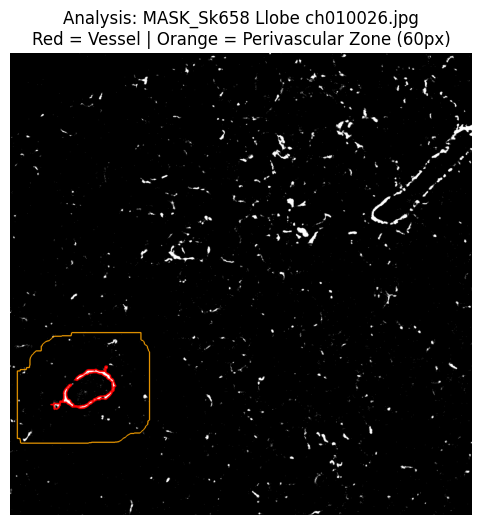

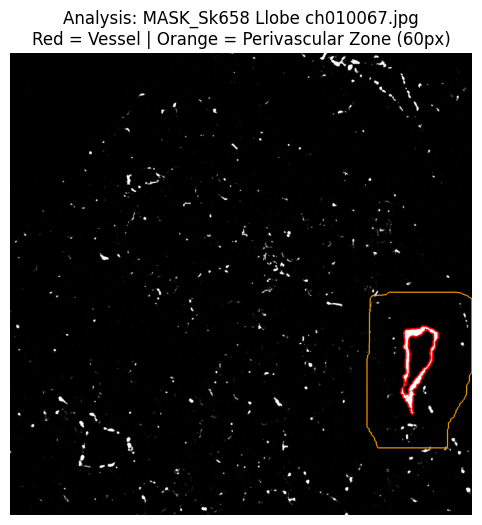

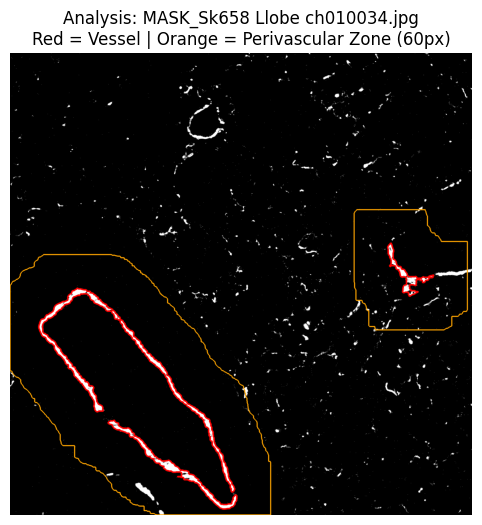

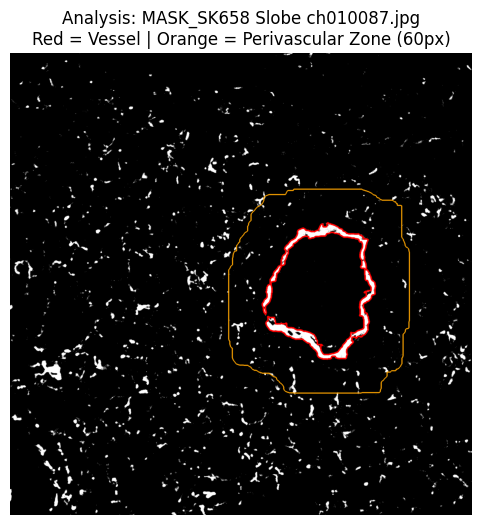

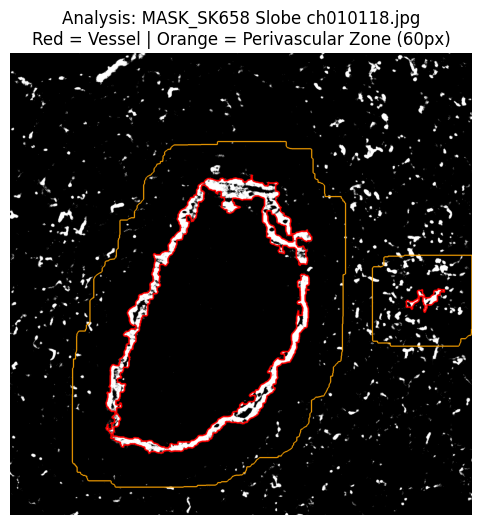

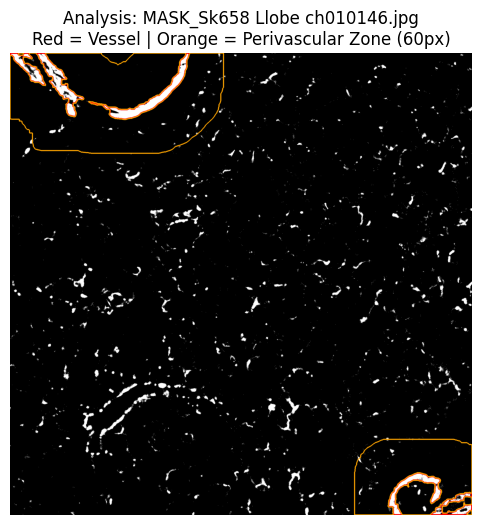

,Filename,Proximal_Density_%,Distal_Density_%
0,MASK_Sk658 Llobe ch010026.jpg,0.99,1.63
1,MASK_Sk658 Llobe ch010067.jpg,1.08,1.14
2,MASK_Sk658 Llobe ch010034.jpg,0.97,1.25
3,MASK_SK658 Slobe ch010087.jpg,1.64,3.00
4,MASK_SK658 Slobe ch010118.jpg,1.97,3.42
5,MASK_Sk658 Llobe ch010146.jpg,1.37,2.45


In [75]:
# --- SETUP ---
Location = r"C:\Users\kaits\OneDrive\Desktop\BME2315\Module-3-Fibrosis"

filenames_raw = [
    "MASK_Sk658 Llobe ch010026.jpg",
    "MASK_Sk658 Llobe ch010067.jpg",
    "MASK_Sk658 Llobe ch010034.jpg",
    "MASK_SK658 Slobe ch010087.jpg",
    "MASK_SK658 Slobe ch010118.jpg",
    "MASK_Sk658 Llobe ch010146.jpg"
]

# Create full paths
filenames = [os.path.join(Location, "images", f) for f in filenames_raw]
results_list = []
proximal_list = []
distal_list = []


# --- PROCESSING LOOP ---
for full_path in filenames:
    # Load image as grayscale
    img = cv2.imread(full_path, 0)
    
    if img is None:
        print(colored(f"Could not load: {full_path}", "red"))
        continue

    # 1. CLEANING THE IMAGE
    # Median blur removes small white noise/specks
    denoised = cv2.medianBlur(img, 5)
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)
    
    # Morphological Closing bridges small gaps in the vessel walls
    kernel_bridge = np.ones((15, 15), np.uint8)
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_bridge)

    # 2. FINDING THE VESSELS (RED CIRCLES)
    contours, hierarchy = cv2.findContours(closed, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    
    vessel_mask = np.zeros_like(img) 
    # Create a color version for plotting (BGR to RGB for Matplotlib)
    display_img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    vessels_found = 0

    if hierarchy is not None:
        for idx, cnt in enumerate(contours):
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0 or area < 1500: continue
           
            # Logic to identify a vessel (roundness and presence of a hole/lumen)
            circularity = 4 * np.pi * (area / (perimeter * perimeter))
            has_hole = hierarchy[0][idx][2] != -1
            
            if (has_hole and circularity > 0.2) or (area > 5000):
                vessels_found += 1
                # Fill the vessel in our internal mask
                cv2.drawContours(vessel_mask, [cnt], -1, 255, -1)
                # Draw the RED identification circle on the display image
                cv2.drawContours(display_img, [cnt], -1, (255, 0, 0), 5) # Red in RGB

    # 3. CREATING THE PROXIMITY REGION (ORANGE RING)
    if vessels_found > 0:
        # Dilate (expand) the vessel mask by 0 pixels to create the outer boundary
        kernel_dil = np.ones((300, 300), np.uint8)
        dilated = cv2.dilate(vessel_mask, kernel_dil, iterations=1)
        
        # Subtract the vessel from the dilated area to get only the ring around it
        proximal_mask = cv2.subtract(dilated, vessel_mask)

        # Draw the ORANGE proximity circle on the display image
        ring_contours, _ = cv2.findContours(proximal_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(display_img, ring_contours, -1, (255, 165, 0), 3) # Orange in RGB

        # 4. DENSITY CALCULATIONS
        _, raw_binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
        
        # Count white pixels (fibrosis) inside the orange ring
        proximal_white = np.sum((raw_binary == 255) & (proximal_mask == 255))
        proximal_total = np.sum(proximal_mask == 255)
        proximal_dens = (proximal_white / proximal_total * 100) if proximal_total > 0 else 0.0

        # Count white pixels in the Parenchyma (everywhere else)
        excluded_space = cv2.bitwise_or(vessel_mask, proximal_mask)
        distal_mask = cv2.bitwise_not(excluded_space)
        distal_white = np.sum((raw_binary == 255) & (distal_mask == 255))
        distal_total = np.sum(distal_mask == 255)
        distal_dens = (distal_white / distal_total * 100) if distal_total > 0 else 0.0
    else:
        proximal_dens, distal_dens = -1, -1

    # Store results
    results_list.append({
        "Filename": os.path.basename(full_path),
        "Proximal_Density_%": round(proximal_dens, 2),
        "Distal_Density_%": round(distal_dens, 2)
    })
    proximal_list.append(proximal_dens)
    distal_list.append(distal_dens)

    # --- PLOT THE RESULT ---
    plt.figure(figsize=(10, 6))
    plt.imshow(display_img)
    plt.title(f"Analysis: {os.path.basename(full_path)}\nRed = Vessel | Orange = Perivascular Zone (60px)")
    plt.axis('off')
    plt.show()

# --- DISPLAY DATA TABLE ---
df_results = pd.DataFrame(results_list)
display(df_results) 

##### 4.2 Statistical Significance

Since the Proximal and Distal Density data is related (they both came from the same image in the same density), we implement a Paired T-Test. 

In [76]:
from scipy import stats

# Use the PAIRED T-Test because both measurements come from the same image
t_stat, p_val = stats.ttest_rel(proximal_list, distal_list)

print(f"Paired T-Test P-Value: {p_val:.4f}")

#Check for Significance
if p_val < 0.05:
    print(colored("RESULT: SIGNIFICANT DIFFERENCE", "green", attrs=['bold']))
    print("The fibrosis levels are statistically different between the two regions.")
else:
    print(colored("RESULT: NOT SIGNIFICANT", "red", attrs=['bold']))
    print("There is not enough evidence to say the regions are different at this sample size.")

Paired T-Test P-Value: 0.0181
RESULT: SIGNIFICANT DIFFERENCE
The fibrosis levels are statistically different between the two regions.


## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*

Duhig, E. E. (2022). Usual interstitial pneumonia: A review of the pathogenesis and discussion of elastin fibres, type II pneumocytes and proposed roles in the pathogenesis. Pathology, 54(5), 517–525. https://doi.org/10.1016/j.pathol.2022.05.002

Rozenberg, D., Sitzer, N., Porter, S., Weiss, A., Colman, R., Reid, W. D., Shapera, S., Fisher, J., & Wentlandt, K. (2020). Idiopathic Pulmonary Fibrosis: A Review of Disease, Pharmacological, and Nonpharmacological Strategies With a Focus on Symptoms, Function, and Health-Related Quality of Life. Journal of pain and symptom management, 59(6), 1362–1378. https://doi.org/10.1016/j.jpainsymman.2019.12.364

Leonard-Duke, J., Agro, S. M. J., Csordas, D. J., Bruce, A. C., Eggertsen, T. G., Tavakol, T. N., Barker, T. H., Bonham, C. A., Saucerman, J. J., Taite, L. J., & Peirce, S. M. (2024). Multiscale computational model predicts how environmental changes and drug treatments affect microvascular remodeling in fibrotic disease. bioRxiv : the preprint server for biology, 2024.03.15.585249. https://doi.org/10.1101/2024.03.15.585249